### raccolta piccoli test fatti per decidere le varie cose che potremmo aggiungere a mo di appendice 

* test to understand how clahe works and tuning for our images
* test different histogram equilizers
* scelta se clahe o no in combo con filtering
* scelta sobel o canny e dove
*  ecc


In [2]:
### SETUP
import numpy as np
import cv2
from matplotlib import pyplot as plt
import math

## test CLAHE
[Documentation about CLAHE and other histogram equilizers](https://docs.opencv.org/4.x/d5/daf/tutorial_py_histogram_equalization.html)

RESULT: CLAHE can give a nice improvement on the image by enhancing the shadow of the liner and the details/defects, it expands a bit the range of intensities used (even if not to 100% of the 0-255 range) so it gives "more freedom" in fining the adequate threshold of canny/sobel to find the conturs/features

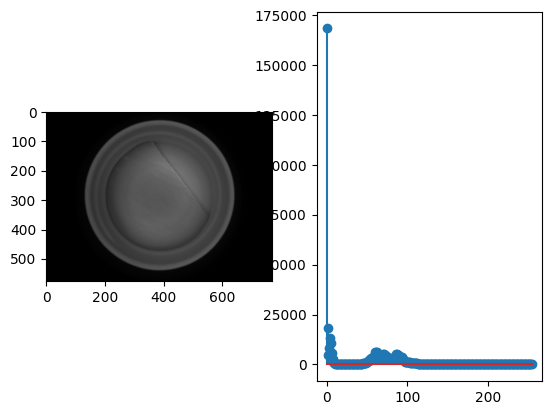

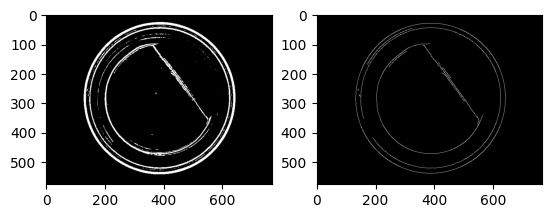

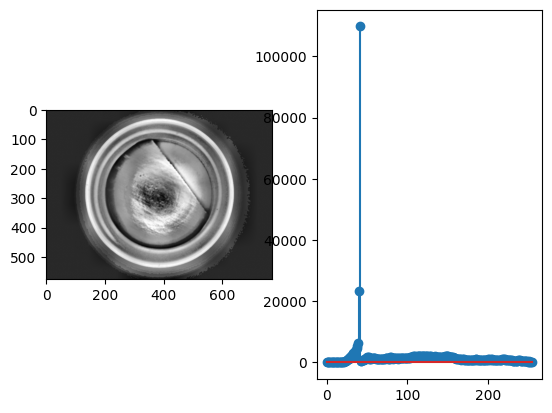

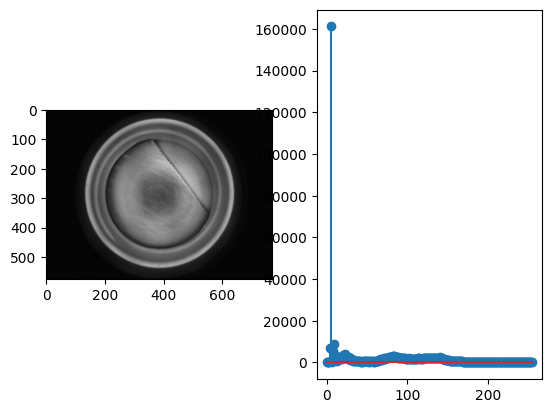

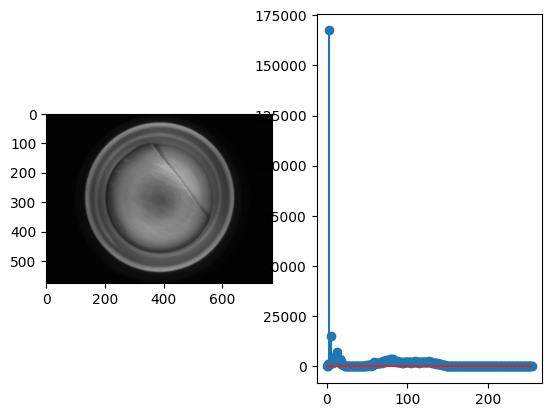

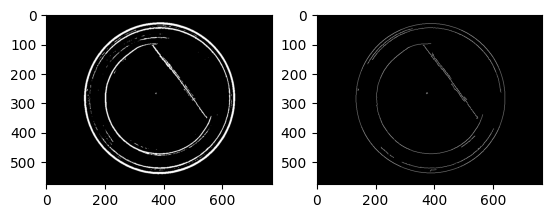

In [ ]:
img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/d_17.bmp')
img = cv2.cvtColor(img_color,cv2.COLOR_BGR2GRAY)
img = cv2.GaussianBlur(img,(7,7),0)

hist, bins = np.histogram(img.flatten(), 256, [0,256])
plt.figure()
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray',vmin=0,vmax=255)
plt.subplot(1,2,2)
plt.stem(hist)
plt.show()

sobelx = cv2.Sobel(img,cv2.CV_64F,1,0,ksize=3)
sobely = cv2.Sobel(img,cv2.CV_64F,0,1,ksize=3)
sobel = cv2.convertScaleAbs(cv2.magnitude(sobelx, sobely))
th ,sobel_bin =  cv2.threshold(sobel, 15, 255, cv2.THRESH_BINARY)

canny=cv2.Canny(img,15,30)

plt.figure()
plt.subplot(1,2,1)
plt.imshow(sobel_bin,cmap='gray',vmin=0,vmax=255)
plt.subplot(1,2,2)
plt.imshow(canny,cmap='gray',vmin=0,vmax=255)
plt.show()
## definetely need some filtering either gaussian or bilateral (to preserve the edges)


cl1 = cv2.createCLAHE(clipLimit=40.0, tileGridSize=(8,8)).apply(img) #default values

hist_cl, bins_cl = np.histogram(cl1.flatten(), 256, [0,256])
plt.figure()
plt.subplot(1,2,1)
plt.imshow(cl1,cmap='gray',vmin=0,vmax=255)
plt.subplot(1,2,2)
plt.stem(hist_cl)
plt.show()

#con:  create aura around cap enhances parts we don't need
#pro: makes the shadow of the liner extra dark (considering a roi could be nice)
# CON: need to super increase thresholds in sobel/canny to find useful things  - 100/200

#REDUCE CLIP LIMIT



cl1 = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8)).apply(img)

hist_cl, bins_cl = np.histogram(cl1.flatten(), 256, [0,256])
plt.figure()
plt.subplot(1,2,1)
plt.imshow(cl1,cmap='gray',vmin=0,vmax=255)
plt.subplot(1,2,2)
plt.stem(hist_cl)
plt.show()

#much better
# way less "artifacts", still good enhancing of the liner shadows
# nicer threshold values for sobel/canny - 50/110
#try changing gridSize


cl1 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(5,5)).apply(img)

hist_cl, bins_cl = np.histogram(cl1.flatten(), 256, [0,256])
plt.figure()
plt.subplot(1,2,1)
plt.imshow(cl1,cmap='gray',vmin=0,vmax=255)
plt.subplot(1,2,2)
plt.stem(hist_cl)
plt.show()

#very nice results
#in some images some finer useful details are kept in canny without noise - d_16 little defects at bottom left "corner" in liner

#DOUBLE CHECK WHAT USEFUL INFO IS FOUND

sobelx = cv2.Sobel(cl1,cv2.CV_64F,1,0,ksize=3)
sobely = cv2.Sobel(cl1,cv2.CV_64F,0,1,ksize=3)
sobel = cv2.convertScaleAbs(cv2.magnitude(sobelx, sobely))
th ,sobel_bin =  cv2.threshold(sobel, 40, 255, cv2.THRESH_BINARY)

canny=cv2.Canny(cl1,35,70)

plt.figure()
plt.subplot(1,2,1)
plt.imshow(sobel_bin,cmap='gray',vmin=0,vmax=255)
plt.subplot(1,2,2)
plt.imshow(canny,cmap='gray',vmin=0,vmax=255)
plt.show()

## test combination clahe and gaussian/bilateral filter

RESULT: applying clahe and then the filter gives the better result with a nice enhanced and denoised image. Between gaussian and bilateral filter (which give very similar results) even if theoretically speaking bilateral should make more sense because it is made to remove gaussian noise WHILE preservinge the edges, the gaussian filter stil does a great job at maintaing nice edges with these pictures AND it is what CANNY "calls for" so we are going to use the gaussian filter

choice of parameters: kernel size (7,7) gave nice results with the image size,resolution,etc we have and the sigma value is chosen with the rule of thumb (kernel_size=2*(cieling(3*sigma)+1)) and by checking it works ok to 1.5

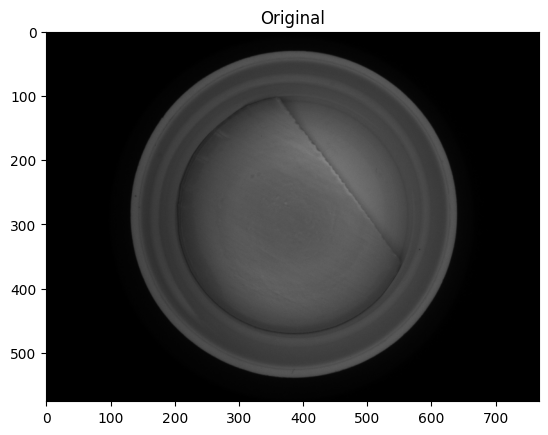

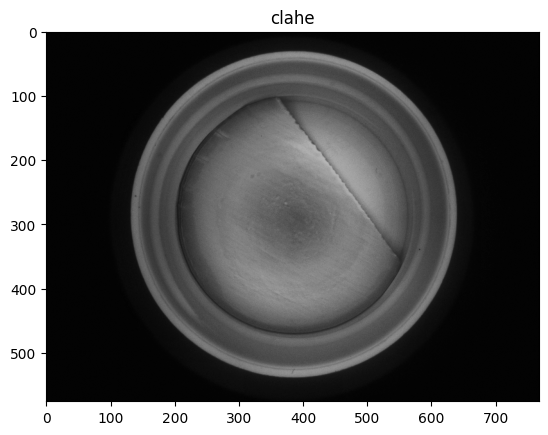

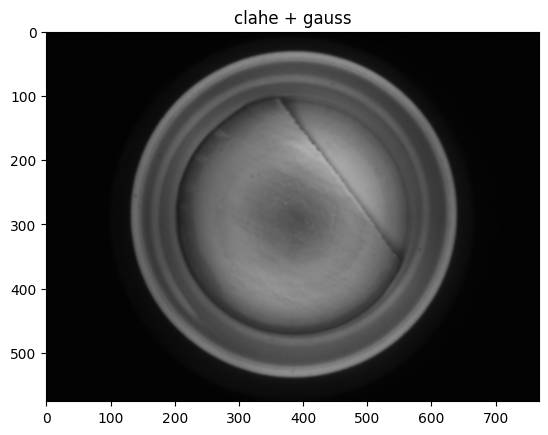

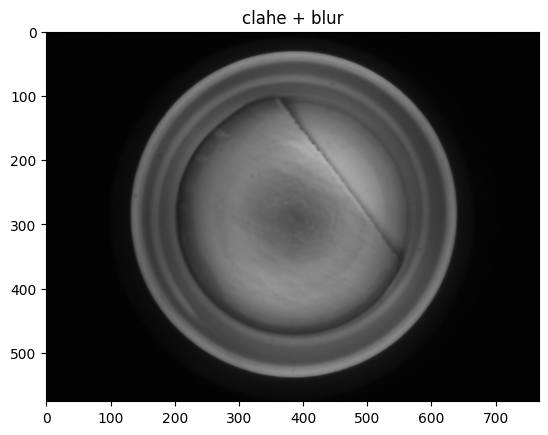

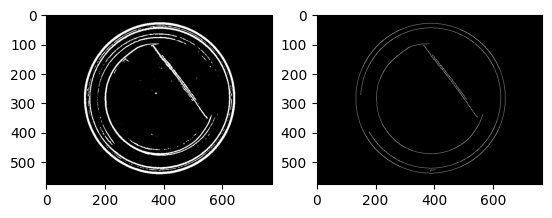

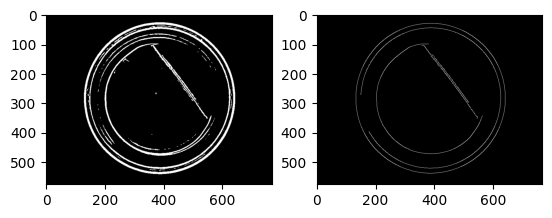

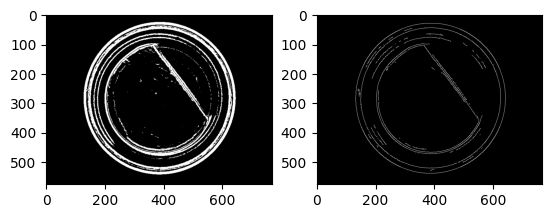

In [ ]:
img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/d_17.bmp')
img = cv2.cvtColor(img_color,cv2.COLOR_BGR2GRAY)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(5,5))


img_gauss = cv2.GaussianBlur(img,(7,7),1.5)
img_blur = cv2.bilateralFilter(img,7,50,75)

img_cl = clahe.apply(img)

img_blur_cl = clahe.apply(img_blur)

img_cl_gauss = cv2.GaussianBlur(img_cl,(7,7),1.5)
img_cl_blur = cv2.bilateralFilter(img_cl,7,45,75) ##very good results

img_blur_cl_blur = cv2.bilateralFilter(clahe.apply(img_blur),7,50,75)



plt.figure()
plt.title("Original")
plt.imshow(img,cmap='gray',vmin=0,vmax=255)
plt.show()
'''
plt.figure()
plt.title("gauss")
plt.imshow(img_gauss,cmap='gray',vmin=0,vmax=255)
plt.show()

plt.figure()
plt.title("blur")
plt.imshow(img_blur,cmap='gray',vmin=0,vmax=255)
plt.show()
'''
plt.figure()
plt.title("clahe")
plt.imshow(img_cl,cmap='gray',vmin=0,vmax=255)
plt.show()


plt.figure()
plt.title("clahe + gauss")
plt.imshow(img_cl_gauss,cmap='gray',vmin=0,vmax=255)
plt.show()

plt.figure()
plt.title("clahe + blur")
plt.imshow(img_cl_blur,cmap='gray',vmin=0,vmax=255)
plt.show()



'''
plt.figure()
plt.title("blur + clahe")
plt.imshow(img_blur_cl,cmap='gray',vmin=0,vmax=255)
plt.show()

plt.figure()
plt.title("blur + clahe + blur")
plt.imshow(img_blur_cl_blur,cmap='gray',vmin=0,vmax=255)
plt.show()
'''


#test comparisons of sobel and canny

sobelx = cv2.Sobel(img_cl_gauss,cv2.CV_64F,1,0,ksize=3)
sobely = cv2.Sobel(img_cl_gauss,cv2.CV_64F,0,1,ksize=3)
sobel = cv2.convertScaleAbs(cv2.magnitude(sobelx, sobely))
th ,sobel_bin =  cv2.threshold(sobel, 30, 255, cv2.THRESH_BINARY)

canny=cv2.Canny(img_cl_gauss,35,70)

plt.figure()
plt.subplot(1,2,1)
plt.imshow(sobel_bin,cmap='gray',vmin=0,vmax=255)
plt.subplot(1,2,2)
plt.imshow(canny,cmap='gray',vmin=0,vmax=255)
plt.show()

sobelx = cv2.Sobel(img_cl_blur,cv2.CV_64F,1,0,ksize=3)
sobely = cv2.Sobel(img_cl_blur,cv2.CV_64F,0,1,ksize=3)
sobel = cv2.convertScaleAbs(cv2.magnitude(sobelx, sobely))
th ,sobel_bin =  cv2.threshold(sobel, 30, 255, cv2.THRESH_BINARY)

canny=cv2.Canny(img_cl_blur,35,70)

plt.figure()
plt.subplot(1,2,1)
plt.imshow(sobel_bin,cmap='gray',vmin=0,vmax=255)
plt.subplot(1,2,2)
plt.imshow(canny,cmap='gray',vmin=0,vmax=255)
plt.show()

#original image - uses lower threshold because has overall lower intensity wrt result of clahe
sobelx = cv2.Sobel(img_blur,cv2.CV_64F,1,0,ksize=3)
sobely = cv2.Sobel(img_blur,cv2.CV_64F,0,1,ksize=3)
sobel = cv2.convertScaleAbs(cv2.magnitude(sobelx, sobely))
th ,sobel_bin =  cv2.threshold(sobel, 10, 255, cv2.THRESH_BINARY)

canny=cv2.Canny(img_blur,10,20)

plt.figure()
plt.subplot(1,2,1)
plt.imshow(sobel_bin,cmap='gray',vmin=0,vmax=255)
plt.subplot(1,2,2)
plt.imshow(canny,cmap='gray',vmin=0,vmax=255)
plt.show()




### sobel and canny for "feature detection" 

With the previous test we found the range of values for the threshold to use in either canny or sobel that allow to extract the conturs of the cap and of the liner (if present) as precisely and competely and with as little noise and extra "information" (cap skrew thread) as possible

For Canny: higher threshold should be around 70 and lower threshold 30-35 

For Sobel: threshold should be around 30-35 


Canny is made up by Sobel + Non-Minima-Suppression + hysteresis thresholding. Overall it provides a more concise and useful information especially for shape detection. 
We also tested Sobel (combined with a thresholding step) to see better the information it extracted and try to see if it could be used more flexibly in place of Canny. ( [documentation for use of Sobel](https://opencv.org/edge-detection-using-opencv/#h-sobel-operator) )

For the "circle detection" both at the beginning of the first task and for the second task, neither has to be done explicitely: the function HoughCircles already has an "integrated" Canny, whose threshold is set through the "param1" argument (higher threshold=param1 and lower threshold=param1/2) ( [tutorial](https://docs.opencv.org/4.x/da/d53/tutorial_py_houghcircles.html) about use of HoughCircles, [function documentation](https://docs.opencv.org/4.x/dd/d1a/group__imgproc__feature.html#ga47849c3be0d0406ad3ca45db65a25d2d) )

## test HoughCircles modes (HOUGH_GRADIENT vs HOUGH_GRADIENT_ALT)

# MAYBE TOGLI IL CONFRONTO MA LASCIA SOLO IL TROVARE I PARAMETRI PER HOUGHCIRCLES 

USEFUL MEMO ABOUT DIFFERENCES: 

**dp**	Inverse ratio of the accumulator resolution to the image resolution. For example, if dp=1 , the accumulator has the same resolution as the input image. If dp=2 , the accumulator has half as big width and height. For HOUGH_GRADIENT_ALT the recommended value is dp=1.5, unless some small very circles need to be detected.

**param1**	First method-specific parameter. In case of HOUGH_GRADIENT and HOUGH_GRADIENT_ALT, it is the higher threshold of the two passed to the Canny edge detector (the lower one is twice smaller). Note that HOUGH_GRADIENT_ALT uses Scharr algorithm to compute image derivatives, so the threshold value should normally be higher, such as 300 or normally exposed and contrasty images.

**param2**	Second method-specific parameter. In case of HOUGH_GRADIENT, it is the accumulator threshold for the circle centers at the detection stage. The smaller it is, the more false circles may be detected. Circles, corresponding to the larger accumulator values, will be returned first. In the case of HOUGH_GRADIENT_ALT algorithm, this is the circle "perfectness" measure. The closer it to 1, the better shaped circles algorithm selects. In most cases 0.9 should be fine. If you want get better detection of small circles, you may decrease it to 0.85, 0.8 or even less. But then also try to limit the search range [minRadius, maxRadius] to avoid many false circles

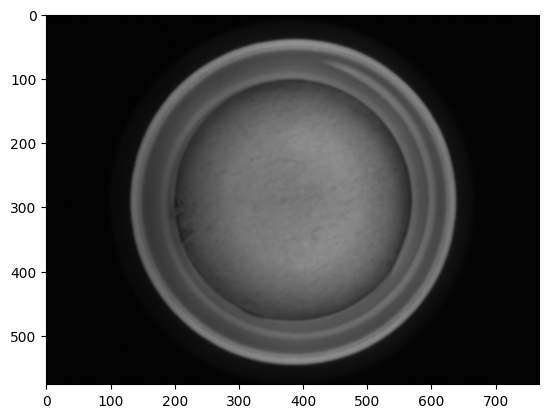

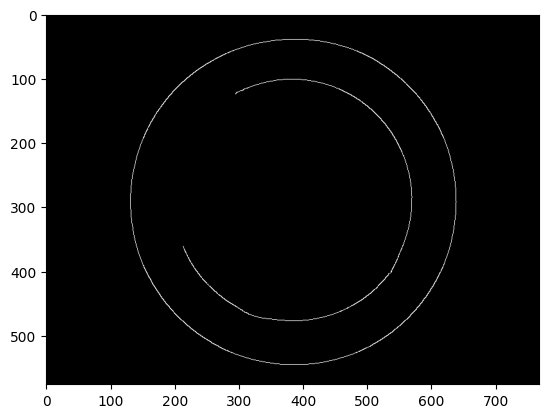

hough_gradient
(1, 1, 3)


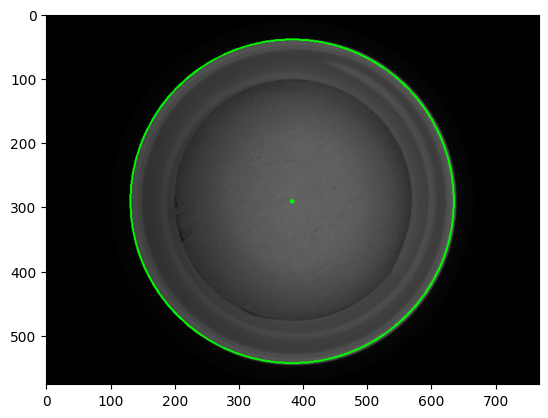

'\nprint("hough_gradient_alt")\n\ncircles_2 = cv2.HoughCircles(img_filt,cv2.HOUGH_GRADIENT_ALT, 1.5, 1,param1=700,param2=0.8)\n\nprint( circles_2.shape)\nimg_color_2 =img_color.copy()\n\nfor c in circles_2[0,:] : \n    cv2.circle(img_color_2,(int(c[0]),int(c[1])),int(c[2]),color=(0, 255, 0),thickness=2)\n    cv2.circle(img_color_2,(int(c[0]),int(c[1])),int(2),color=(0, 255, 0),thickness=2)\n    #print("center: x= ", c[0]," y= ",c[1]," - radius= ",c[2])\n\n\nplt.imshow(img_color_2)\nplt.show()\n'

In [3]:
img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/d_16.bmp')
img = cv2.cvtColor(img_color,cv2.COLOR_BGR2GRAY)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(5,5))
img_cl = clahe.apply(img)
img_filt = cv2.GaussianBlur(img_cl,(7,7),1.5)

plt.figure()
plt.imshow(img_filt,cmap='gray',vmin=0,vmax=255)
plt.show()


edges = cv2.Canny(img_filt,50,100,apertureSize = 3)
plt.imshow(edges,cmap='gray',vmin=0,vmax=255)
plt.show() 

print("hough_gradient")

#circles_1 = cv2.HoughCircles(img_filt,cv2.HOUGH_GRADIENT, 1, 1,param1=70,param2=70) # find around 300 circles (with d_17)
#kept argument dst=1 to try finding both outside and liner contur at once
# increase param1 to have more essential canny result, increase param2 to have less circles
#circles_1 = cv2.HoughCircles(img_filt,cv2.HOUGH_GRADIENT, 1, 1,param1=100,param2=100) # find around 100: clearly see 2 areas (cap and liner) (with d_17)
#circles_1 = cv2.HoughCircles(img_filt,cv2.HOUGH_GRADIENT, 1, 1,param1=110,param2=150) #still find many circles (with d_17)  - find none with d_19 and d_31

#makes more sense to find only the external contur then reduce to a smaller area (ROI) to find the liner contur
#by simply increasing the dst we obtain only the best circles with very different centers - in our case only the outer contur 
#circles_1 = cv2.HoughCircles(img_filt,cv2.HOUGH_GRADIENT, 1, 40,param1=110,param2=100) #great result 
# try to "relax" the param1,param2 to ensure more flexibility/robustness for all images we have
circles_1 = cv2.HoughCircles(img_filt,cv2.HOUGH_GRADIENT, 1, 40,param1=100,param2=70) #great result 

print( circles_1.shape)

img_color_1 =img_color.copy()

for c in circles_1[0,:] : 
    cv2.circle(img_color_1,(int(c[0]),int(c[1])),int(c[2]),color=(0, 255, 0),thickness=2)
    cv2.circle(img_color_1,(int(c[0]),int(c[1])),int(2),color=(0, 255, 0),thickness=2)
    #print("center: x= ", c[0]," y= ",c[1]," - radius= ",c[2])


plt.imshow(img_color_1)
plt.show()
'''
print("hough_gradient_alt")

circles_2 = cv2.HoughCircles(img_filt,cv2.HOUGH_GRADIENT_ALT, 1.5, 1,param1=700,param2=0.8)

print( circles_2.shape)
img_color_2 =img_color.copy()

for c in circles_2[0,:] : 
    cv2.circle(img_color_2,(int(c[0]),int(c[1])),int(c[2]),color=(0, 255, 0),thickness=2)
    cv2.circle(img_color_2,(int(c[0]),int(c[1])),int(2),color=(0, 255, 0),thickness=2)
    #print("center: x= ", c[0]," y= ",c[1]," - radius= ",c[2])


plt.imshow(img_color_2)
plt.show()
'''